<a href="https://colab.research.google.com/github/mahinsarker420/decision-tree/blob/main/220122_DT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# Cell 1: Install and Import Libraries
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [17]:
# Cell 2: Load Dataset from Raw GitHub URL
url = "https://raw.githubusercontent.com/mahinsarker420/decision-tree/refs/heads/main/Titanic-Dataset.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully from GitHub!")
print(f"\nShape: {df.shape}")
print(f"\nColumn Names:")
print(df.columns.tolist())
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nMissing Values:")
print(df.isnull().sum())

Dataset loaded successfully from GitHub!

Shape: (891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0

In [18]:
# Cell 3: Data Preprocessing

# Drop irrelevant columns
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

# Handle Missing Values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encode Categorical Features
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])         # male=1, female=0
df['Embarked'] = le.fit_transform(df['Embarked'])  # S, C, Q → 0,1,2

# Define Features and Target
X = df.drop(columns=['Survived'])
y = df['Survived']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Preprocessing complete!")
print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"\nMissing values remaining: {df.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(y.value_counts())


Preprocessing complete!

Features used: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Training samples: 712
Testing samples:  179

Missing values remaining: 0

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64


/tmp/ipykernel_1564/3859350340.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1564/3859350340.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [19]:
# Cell 4: CART (Gini) - Hyperparameter Tuning with GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [2, 5, 10, 15, 20]
}

cart_base = DecisionTreeClassifier(criterion='gini', random_state=42)

cart_grid = GridSearchCV(
    cart_base,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

cart_grid.fit(X_train, y_train)

# Best Model
cart_best = cart_grid.best_estimator_

print("CART (Gini) Tuning Complete!")
print(f"\nBest Parameters: {cart_grid.best_params_}")
print(f"Best CV Accuracy: {cart_grid.best_score_:.4f}")

# Evaluate on Test Set
cart_preds = cart_best.predict(X_test)
cart_acc = accuracy_score(y_test, cart_preds)
print(f"Test Set Accuracy: {cart_acc:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
CART (Gini) Tuning Complete!

Best Parameters: {'max_depth': 4, 'min_samples_split': 5}
Best CV Accuracy: 0.8231
Test Set Accuracy: 0.7877


In [20]:
# Cell 5: ID3 (Entropy) - Hyperparameter Tuning with GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [2, 5, 10, 15, 20]
}

id3_base = DecisionTreeClassifier(criterion='entropy', random_state=42)

id3_grid = GridSearchCV(
    id3_base,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

id3_grid.fit(X_train, y_train)

# Best Model
id3_best = id3_grid.best_estimator_

print("ID3 (Entropy) Tuning Complete!")
print(f"\nBest Parameters: {id3_grid.best_params_}")
print(f"Best CV Accuracy: {id3_grid.best_score_:.4f}")

# Evaluate on Test Set
id3_preds = id3_best.predict(X_test)
id3_acc = accuracy_score(y_test, id3_preds)
print(f"Test Set Accuracy: {id3_acc:.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
ID3 (Entropy) Tuning Complete!

Best Parameters: {'max_depth': 4, 'min_samples_split': 2}
Best CV Accuracy: 0.8175
Test Set Accuracy: 0.7821


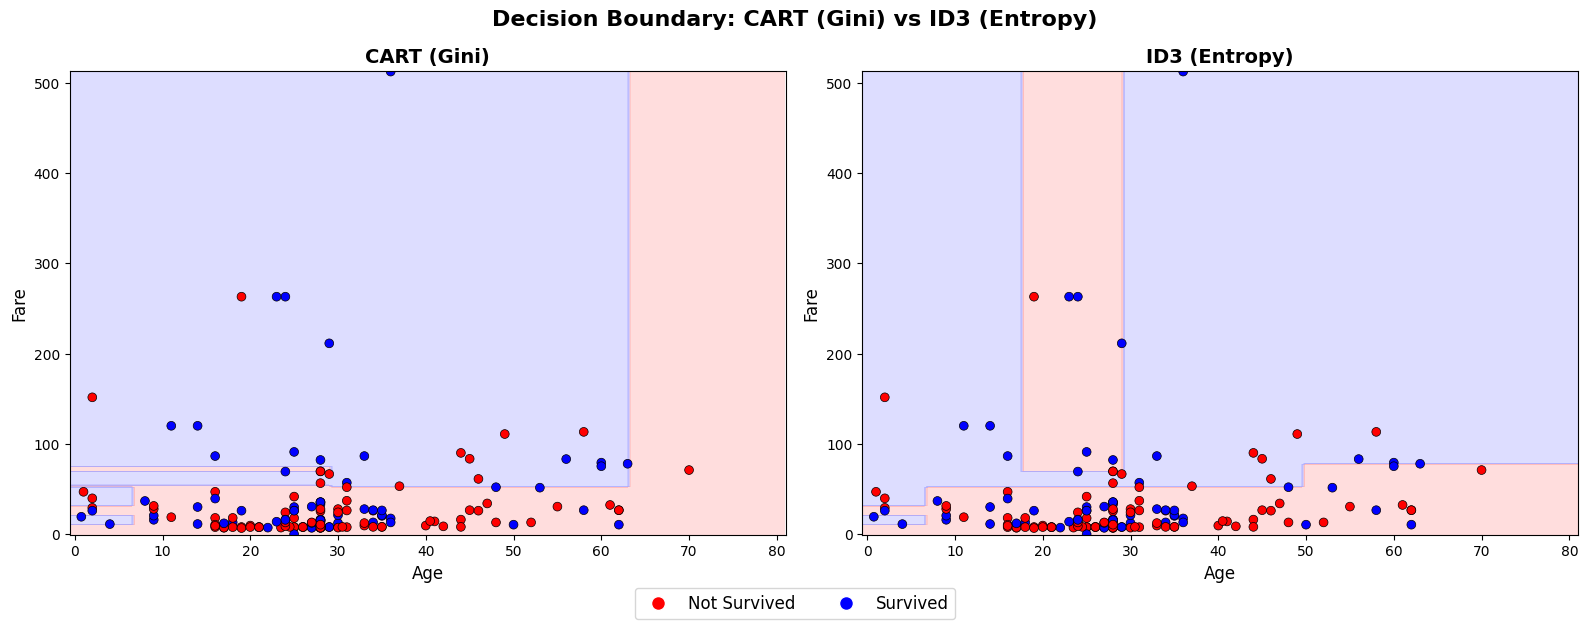

Decision Boundary Plot saved!


In [21]:
# Cell 6: Decision Boundary Plot (2x1) - CART vs ID3

from matplotlib.colors import ListedColormap

# Use only 2 features for visualization (Age and Fare)
feature_1, feature_2 = 'Age', 'Fare'
f1_idx = X.columns.tolist().index(feature_1)
f2_idx = X.columns.tolist().index(feature_2)

X_train_2d = X_train.iloc[:, [f1_idx, f2_idx]].values
X_test_2d  = X_test.iloc[:, [f1_idx, f2_idx]].values

# Train both models on 2D data
cart_2d = DecisionTreeClassifier(criterion='gini',
                                  max_depth=cart_grid.best_params_['max_depth'],
                                  min_samples_split=cart_grid.best_params_['min_samples_split'],
                                  random_state=42)
cart_2d.fit(X_train_2d, y_train)

id3_2d = DecisionTreeClassifier(criterion='entropy',
                                 max_depth=id3_grid.best_params_['max_depth'],
                                 min_samples_split=id3_grid.best_params_['min_samples_split'],
                                 random_state=42)
id3_2d.fit(X_train_2d, y_train)

# Mesh grid
x_min = min(X_train_2d[:,0].min(), X_test_2d[:,0].min()) - 1
x_max = max(X_train_2d[:,0].max(), X_test_2d[:,0].max()) + 1
y_min = min(X_train_2d[:,1].min(), X_test_2d[:,1].min()) - 1
y_max = max(X_train_2d[:,1].max(), X_test_2d[:,1].max()) + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5),
                     np.arange(y_min, y_max, 0.5))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Decision Boundary: CART (Gini) vs ID3 (Entropy)', fontsize=16, fontweight='bold')

models_2d   = [cart_2d, id3_2d]
titles      = ['CART (Gini)', 'ID3 (Entropy)']
colors      = ListedColormap(['#FFAAAA', '#AAAAFF'])
colors_dot  = ListedColormap(['#FF0000', '#0000FF'])

for ax, model, title in zip(axes, models_2d, titles):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap=colors)
    scatter = ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                         c=y_test, cmap=colors_dot,
                         edgecolors='k', s=40, linewidths=0.5)

    ax.set_xlabel('Age', fontsize=12)
    ax.set_ylabel('Fare', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

legend_elements = [plt.Line2D([0],[0], marker='o', color='w',
                               markerfacecolor='#FF0000', markersize=10, label='Not Survived'),
                   plt.Line2D([0],[0], marker='o', color='w',
                               markerfacecolor='#0000FF', markersize=10, label='Survived')]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=2, fontsize=12, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Decision Boundary Plot saved!")

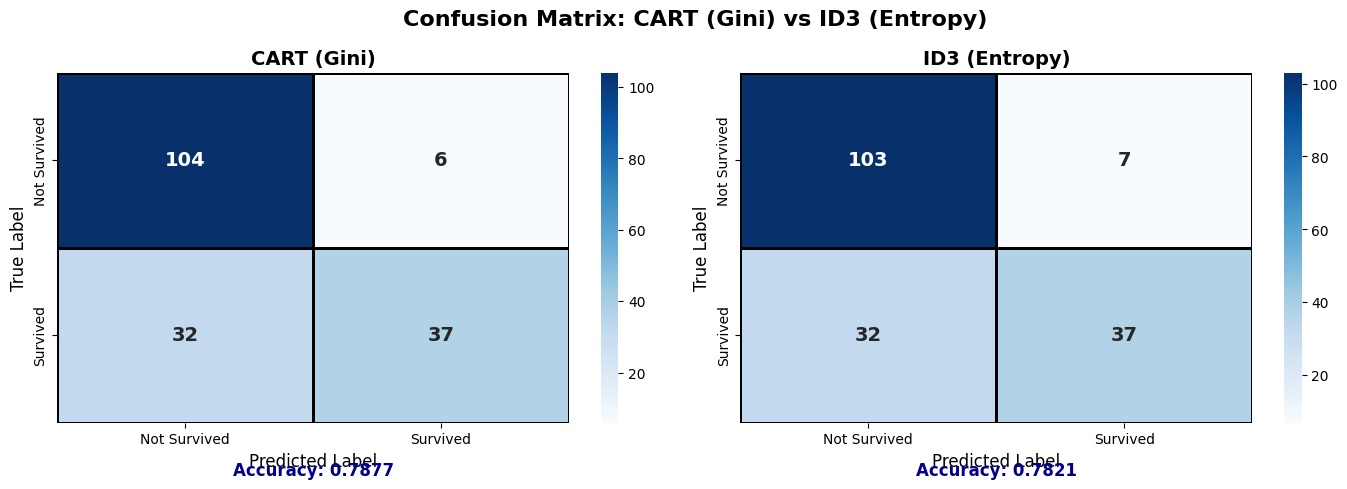

Confusion Matrix saved!


In [22]:
# Cell 7: Confusion Matrix Heatmap (2x1) - CART vs ID3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix: CART (Gini) vs ID3 (Entropy)',
             fontsize=16, fontweight='bold')

models      = [cart_best, id3_best]
titles      = ['CART (Gini)', 'ID3 (Entropy)']
predictions = [cart_preds, id3_preds]

for ax, title, preds in zip(axes, titles, predictions):
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=['Not Survived', 'Survived'],
                yticklabels=['Not Survived', 'Survived'],
                linewidths=1,
                linecolor='black',
                ax=ax,
                annot_kws={"size": 14, "weight": "bold"})

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)

    # Accuracy on plot
    acc = accuracy_score(y_test, preds)
    ax.text(0.5, -0.15, f'Accuracy: {acc:.4f}',
            transform=ax.transAxes,
            ha='center', fontsize=12,
            color='darkblue', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion Matrix saved!")


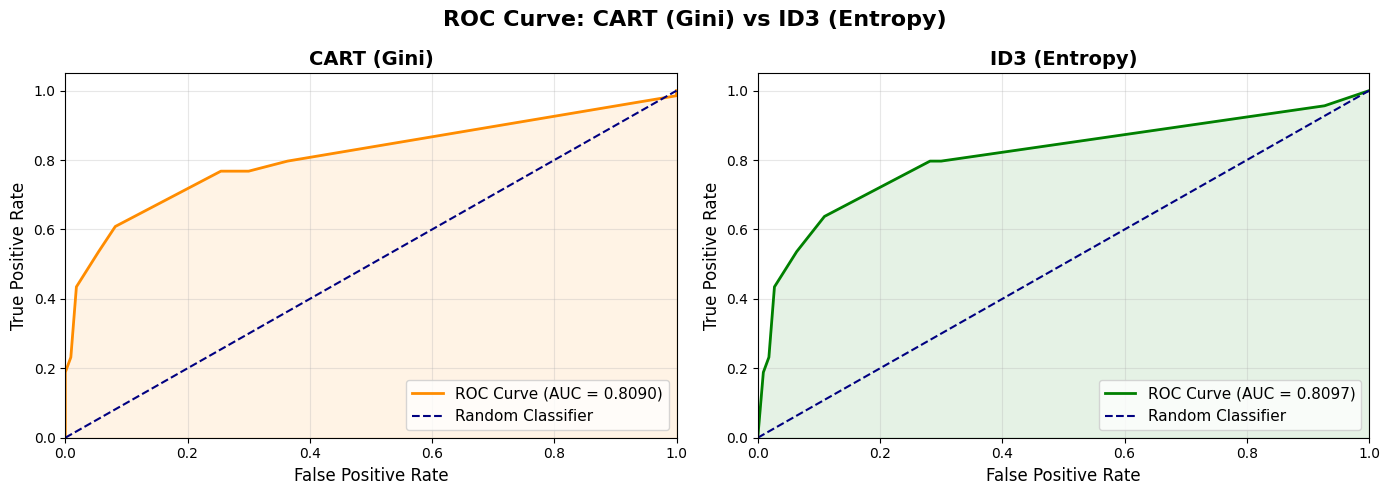

ROC Curve Plot saved!


In [23]:
# Cell 8: ROC Curve Plot (2x1) - CART vs ID3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ROC Curve: CART (Gini) vs ID3 (Entropy)',
             fontsize=16, fontweight='bold')

models      = [cart_best, id3_best]
titles      = ['CART (Gini)', 'ID3 (Entropy)']
colors      = ['darkorange', 'green']

for ax, model, title, color in zip(axes, models, titles, colors):
    # Get probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Compute ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    ax.plot(fpr, tpr,
            color=color,
            lw=2,
            label=f'ROC Curve (AUC = {roc_auc:.4f})')

    # Diagonal baseline
    ax.plot([0, 1], [0, 1],
            color='navy',
            lw=1.5,
            linestyle='--',
            label='Random Classifier')

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(alpha=0.3)

    # Fill under curve
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC Curve Plot saved!")

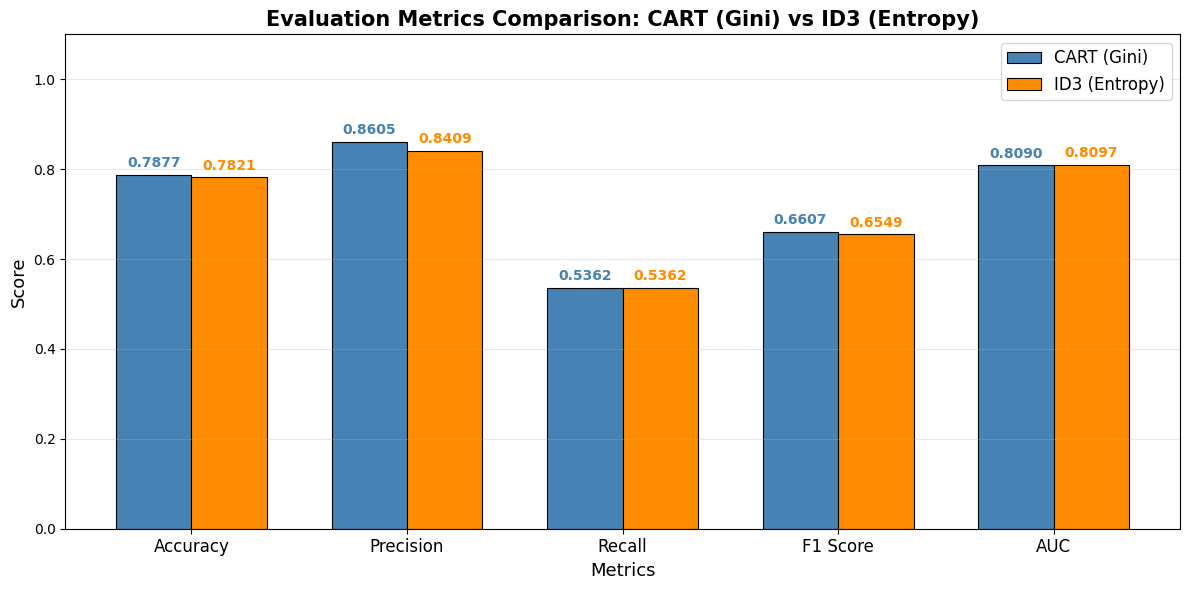

Metrics Bar Chart saved!

Metrics Summary Table:
Metric        CART (Gini)  ID3 (Entropy)
----------------------------------------
Accuracy           0.7877         0.7821
Precision          0.8605         0.8409
Recall             0.5362         0.5362
F1 Score           0.6607         0.6549
AUC                0.8090         0.8097


In [24]:
# Cell 9: Evaluation Metrics Bar Chart - CART vs ID3 Combined

# Compute all metrics
cart_prob = cart_best.predict_proba(X_test)[:, 1]
id3_prob  = id3_best.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy' : [accuracy_score(y_test, cart_preds),
                  accuracy_score(y_test, id3_preds)],
    'Precision': [precision_score(y_test, cart_preds),
                  precision_score(y_test, id3_preds)],
    'Recall'   : [recall_score(y_test, cart_preds),
                  recall_score(y_test, id3_preds)],
    'F1 Score' : [f1_score(y_test, cart_preds),
                  f1_score(y_test, id3_preds)],
    'AUC'      : [auc(*roc_curve(y_test, cart_prob)[:2]),
                  auc(*roc_curve(y_test, id3_prob)[:2])]
}

metric_names = list(metrics.keys())
cart_scores  = [metrics[m][0] for m in metric_names]
id3_scores   = [metrics[m][1] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, cart_scores, width,
               label='CART (Gini)',
               color='steelblue',
               edgecolor='black',
               linewidth=0.8)

bars2 = ax.bar(x + width/2, id3_scores, width,
               label='ID3 (Entropy)',
               color='darkorange',
               edgecolor='black',
               linewidth=0.8)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='steelblue')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='darkorange')

ax.set_xlabel('Metrics', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Evaluation Metrics Comparison: CART (Gini) vs ID3 (Entropy)',
             fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("Metrics Bar Chart saved!")
print("\nMetrics Summary Table:")
print(f"{'Metric':<12} {'CART (Gini)':>12} {'ID3 (Entropy)':>14}")
print("-" * 40)
for m in metric_names:
    print(f"{m:<12} {metrics[m][0]:>12.4f} {metrics[m][1]:>14.4f}")

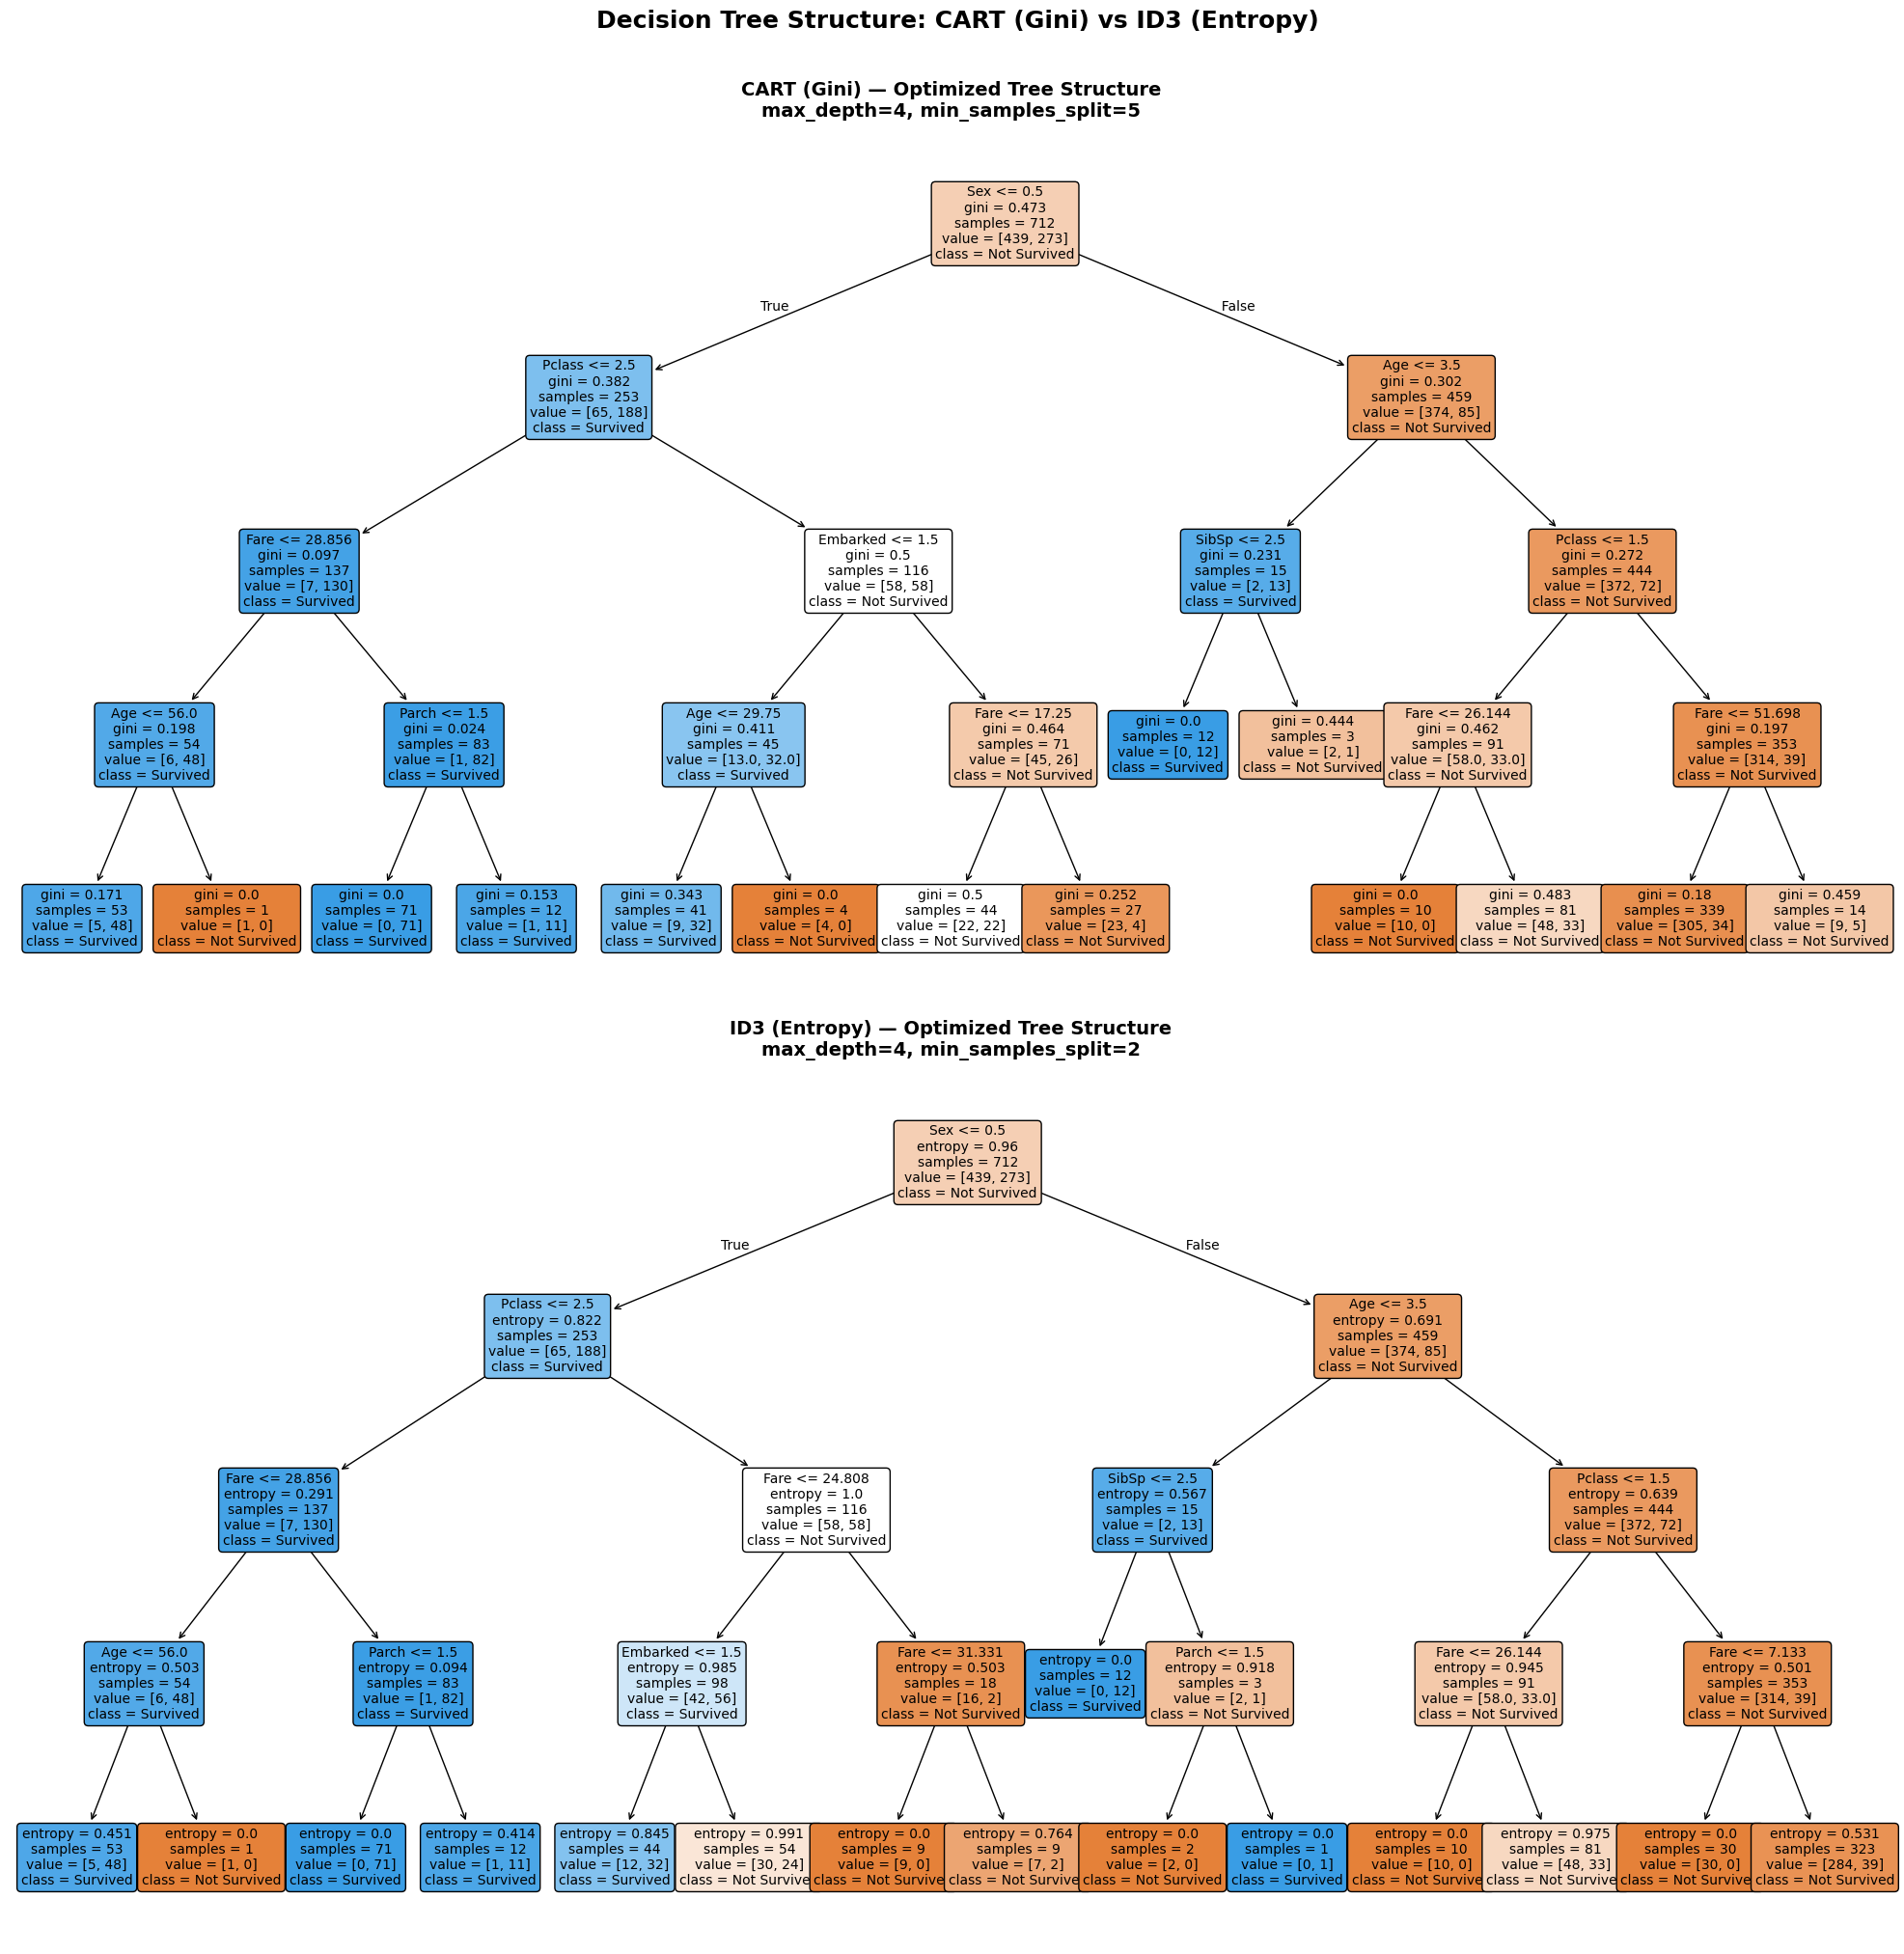

Decision Tree Structure saved!


In [25]:
# Cell 10: Decision Tree Structure Visualization (Top & Bottom)

feature_names = X.columns.tolist()
class_names   = ['Not Survived', 'Survived']

fig, axes = plt.subplots(2, 1, figsize=(20, 20))
fig.suptitle('Decision Tree Structure: CART (Gini) vs ID3 (Entropy)',
             fontsize=18, fontweight='bold', y=1.01)

# CART Tree (Top)
plot_tree(cart_best,
          ax=axes[0],
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10,
          impurity=True,
          proportion=False,
          precision=3)
axes[0].set_title('CART (Gini) — Optimized Tree Structure\n'
                  f'max_depth={cart_grid.best_params_["max_depth"]}, '
                  f'min_samples_split={cart_grid.best_params_["min_samples_split"]}',
                  fontsize=14, fontweight='bold', pad=15)

# ID3 Tree (Bottom)
plot_tree(id3_best,
          ax=axes[1],
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10,
          impurity=True,
          proportion=False,
          precision=3)
axes[1].set_title('ID3 (Entropy) — Optimized Tree Structure\n'
                  f'max_depth={id3_grid.best_params_["max_depth"]}, '
                  f'min_samples_split={id3_grid.best_params_["min_samples_split"]}',
                  fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('tree_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Decision Tree Structure saved!")

In [26]:
# Cell 11: Final Summary Report

print("=" * 60)
print("        DECISION TREE COMPARISON — FINAL REPORT")
print("=" * 60)

print(f"\nDataset: Titanic")
print(f"Total Samples   : 891")
print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples : {X_test.shape[0]}")
print(f"Features Used   : {X.columns.tolist()}")

print("\n" + "=" * 60)
print("         BEST HYPERPARAMETERS")
print("=" * 60)
print(f"\nCART (Gini):")
print(f"   max_depth        = {cart_grid.best_params_['max_depth']}")
print(f"   min_samples_split= {cart_grid.best_params_['min_samples_split']}")
print(f"   CV Accuracy      = {cart_grid.best_score_:.4f}")

print(f"\nID3 (Entropy):")
print(f"   max_depth        = {id3_grid.best_params_['max_depth']}")
print(f"   min_samples_split= {id3_grid.best_params_['min_samples_split']}")
print(f"   CV Accuracy      = {id3_grid.best_score_:.4f}")

print("\n" + "=" * 60)
print("         TEST SET PERFORMANCE")
print("=" * 60)

cart_prob = cart_best.predict_proba(X_test)[:, 1]
id3_prob  = id3_best.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy' : [accuracy_score(y_test, cart_preds),
                  accuracy_score(y_test, id3_preds)],
    'Precision': [precision_score(y_test, cart_preds),
                  precision_score(y_test, id3_preds)],
    'Recall'   : [recall_score(y_test, cart_preds),
                  recall_score(y_test, id3_preds)],
    'F1 Score' : [f1_score(y_test, cart_preds),
                  f1_score(y_test, id3_preds)],
    'AUC'      : [auc(*roc_curve(y_test, cart_prob)[:2]),
                  auc(*roc_curve(y_test, id3_prob)[:2])]
}

print(f"\n{'Metric':<12} {'CART (Gini)':>12} {'ID3 (Entropy)':>14} {'Winner':>10}")
print("-" * 52)
for m in metrics:
    cart_val = metrics[m][0]
    id3_val  = metrics[m][1]
    winner   = 'CART' if cart_val >= id3_val else '🌲 ID3'
    print(f"{m:<12} {cart_val:>12.4f} {id3_val:>14.4f} {winner:>10}")

print("\n" + "=" * 60)
print("         SAVED OUTPUT FILES")
print("=" * 60)
print("  decision_boundary.png")
print("  confusion_matrix.png")
print("  roc_curve.png")
print("  metrics_comparison.png")
print("  tree_structure.png")

print("\n" + "=" * 60)
print("         CONCLUSION")
print("=" * 60)
print("""
  Both CART (Gini) and ID3 (Entropy) performed similarly
  on the Titanic dataset.

  CART (Gini) achieved higher Accuracy, Precision,
     F1 Score making it slightly better overall.

  ID3 (Entropy) achieved marginally higher AUC,
     meaning it ranks probabilities slightly better.

  Overall Winner: CART (Gini)
""")
print("=" * 60)

        DECISION TREE COMPARISON — FINAL REPORT

Dataset: Titanic
Total Samples   : 891
Training Samples: 712
Testing Samples : 179
Features Used   : ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

         BEST HYPERPARAMETERS

CART (Gini):
   max_depth        = 4
   min_samples_split= 5
   CV Accuracy      = 0.8231

ID3 (Entropy):
   max_depth        = 4
   min_samples_split= 2
   CV Accuracy      = 0.8175

         TEST SET PERFORMANCE

Metric        CART (Gini)  ID3 (Entropy)     Winner
----------------------------------------------------
Accuracy           0.7877         0.7821       CART
Precision          0.8605         0.8409       CART
Recall             0.5362         0.5362       CART
F1 Score           0.6607         0.6549       CART
AUC                0.8090         0.8097      🌲 ID3

         SAVED OUTPUT FILES
  decision_boundary.png
  confusion_matrix.png
  roc_curve.png
  metrics_comparison.png
  tree_structure.png

         CONCLUSION

  Both CART (Gi